<a href="https://colab.research.google.com/github/AyotundeOni/AyotundeOni/blob/main/Knowledge_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/Data

/content/drive/MyDrive/Colab Notebooks/Data


In [4]:
import os

# Set your Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = "ayotundeoni"
os.environ['KAGGLE_KEY'] = "84bda9ecd783f0770ad8b4a10332728c"

In [6]:
#I have already download the model RadImageNet IRV2 and also BrATS datsaet for finetunning, I deleted the calls as i ahve them already on my drive.

# Preprocessing and preparing BRaTS dataset for fine tuning.

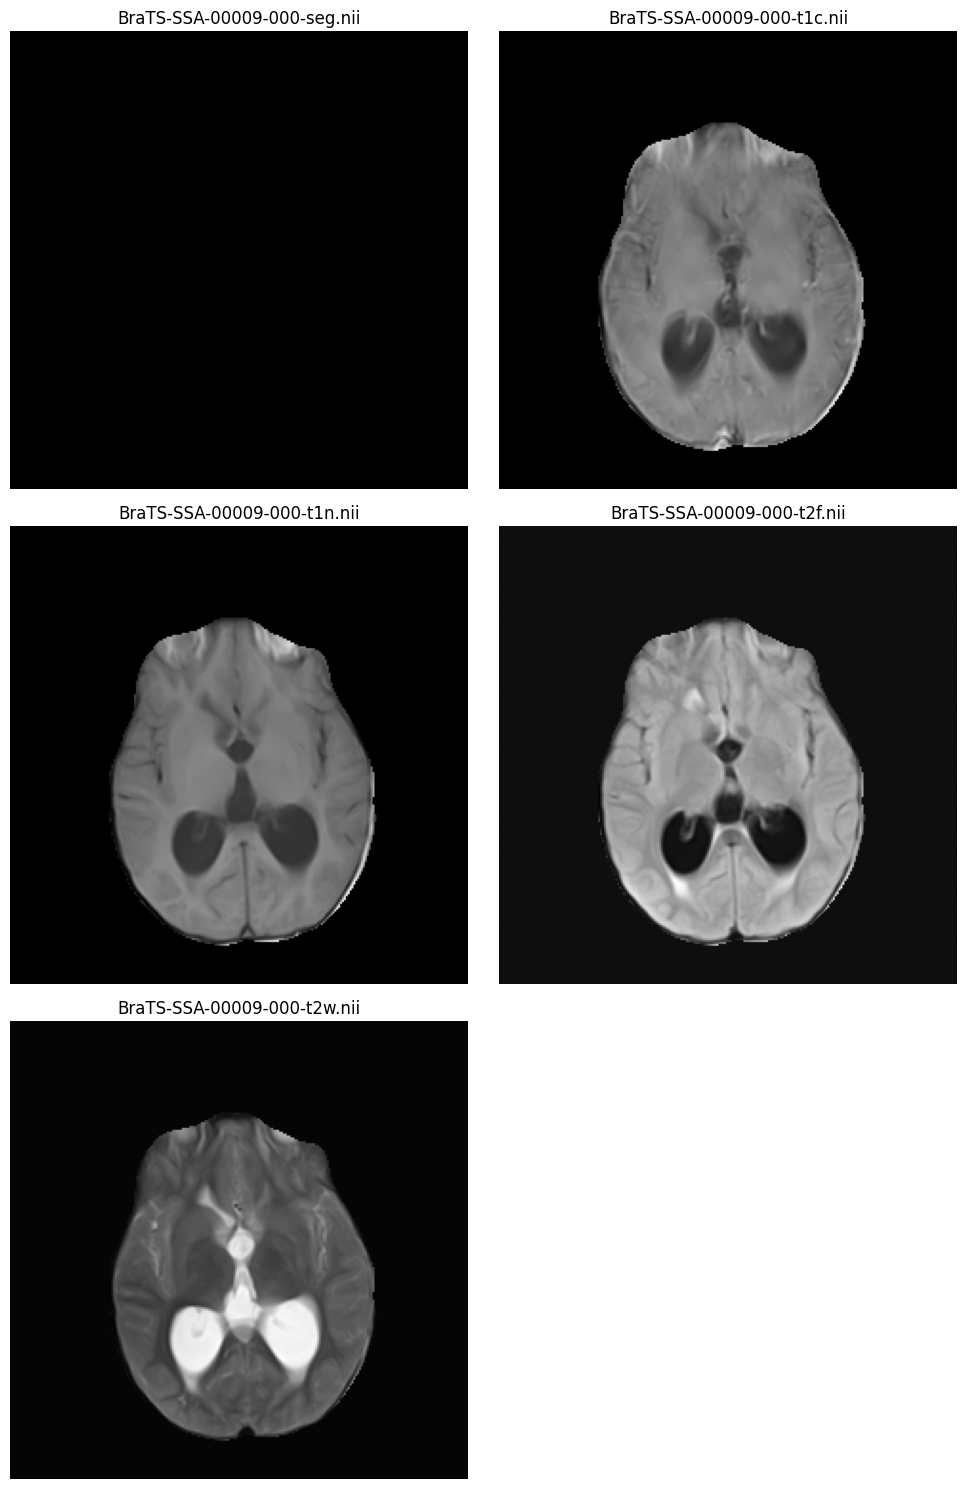

In [16]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
import math

# Change this to the path of the folder containing your .nii or .nii.gz files
folder_path = '/content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00009-000/'

# --- Get a list of all .nii and .nii.gz files in the folder ---
nii_files = [f for f in os.listdir(folder_path) if f.endswith('.nii') or f.endswith('.nii.gz')]

if not nii_files:
    print(f"No .nii or .nii.gz files found in the folder:\n{folder_path}")
else:
    slices_to_display = []
    file_names_to_display = []

    # --- Iterate through each file, get a slice, and store it ---
    for file_name in nii_files:
        file_path = os.path.join(folder_path, file_name)

        try:
            # Load the image using nibabel
            nii_image = nib.load(file_path)

            # Get the image data as a NumPy array
            image_data = nii_image.get_fdata()

            # --- Select a slice to display ---
            if image_data.ndim < 3:
                print(f"Skipping {file_name}: Not a 3D image.")
                continue

            middle_slice_index = image_data.shape[2] // 2
            slice_2d = image_data[:, :, middle_slice_index]

            slices_to_display.append(np.rot90(slice_2d)) # Rotate here to display correctly later
            file_names_to_display.append(file_name)

        except FileNotFoundError:
            print(f"Error: The file was not found at the path:\n{file_path}")
            print("Please make sure the path is correct and your Drive is mounted.")
        except Exception as e:
            print(f"An error occurred while processing {file_name}: {e}")

    # --- Display the slices in a grid ---
    num_images = len(slices_to_display)
    if num_images > 0:
        # Calculate the number of rows and columns for the grid
        cols = 2  # Set the number of columns to 2
        rows = math.ceil(num_images / cols)

        plt.figure(figsize=(cols * 5, rows * 5)) # Adjust figure size based on the number of images

        for i in range(num_images):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(slices_to_display[i], cmap='gray')
            plt.title(file_names_to_display[i])
            plt.axis('off') # Hide the axes

        plt.tight_layout() # Adjust subplot parameters for a tight layout
        plt.show()
    else:
        print("No valid slices were found to display.")

In [22]:
#Voxel alignment

!pip install SimpleITK
import SimpleITK as sitk
from tqdm import tqdm
import os

# These are the main folders containing your patient subfolders
parent_folders_to_process = [
    '/content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms',
    '/content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma'
]


# Aligned files will be saved here. The script will create this folder.
output_folder = '/content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Aligned'
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder is ready at: {output_folder}")

# --- 3. Core Registration Function ---
def register_image(fixed_image_path, moving_image_path, output_path):
    """
    Aligns a moving image to a fixed image and saves the result.
    """
    # Load images
    fixed_image = sitk.ReadImage(fixed_image_path, sitk.sitkFloat32)
    moving_image = sitk.ReadImage(moving_image_path, sitk.sitkFloat32)

    # Set up the registration method
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    registration_method.SetMetricSamplingStrategy(registration_method.RANDOM)
    registration_method.SetMetricSamplingPercentage(0.01)
    registration_method.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=100, estimateLearningRate=registration_method.EachIteration)
    registration_method.SetOptimizerScalesFromPhysicalShift()

    # Set the initial transform
    initial_transform = sitk.CenteredTransformInitializer(fixed_image,
                                                          moving_image,
                                                          sitk.Euler3DTransform(),
                                                          sitk.CenteredTransformInitializerFilter.GEOMETRY)
    registration_method.SetInitialTransform(initial_transform, inPlace=False)

    # Execute the registration
    final_transform = registration_method.Execute(fixed_image, moving_image)

    # Resample the moving image to align it with the fixed image
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_image)
    resampler.SetDefaultPixelValue(0)
    resampler.SetTransform(final_transform)

    # IMPORTANT: Use Nearest Neighbor interpolation for segmentation masks
    if 'seg' in moving_image_path.lower(): # Case-insensitive check
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resampler.SetInterpolator(sitk.sitkLinear)

    aligned_image = resampler.Execute(moving_image)
    sitk.WriteImage(aligned_image, output_path)

# --- 4. Main Loop to Process Specified Parent Folders and their Subfolders ---
all_patient_folders = []
for parent_folder in parent_folders_to_process:
    if os.path.isdir(parent_folder):
        for root, dirs, files in os.walk(parent_folder):
            # Check if the current directory is a patient folder (contains .nii or .nii.gz files)
            if any(f.endswith('.nii') or f.endswith('.nii.gz') for f in files):
                all_patient_folders.append(root)
    else:
        print(f"Warning: Parent folder not found: {parent_folder}")


if not all_patient_folders:
    print(f"No patient folders containing .nii or .nii.gz files found under the specified parent folders.")
else:
    for patient_path in tqdm(all_patient_folders, desc="Processing Patients"):
        # Extract a unique patient ID from the path. This assumes the last part of the path is the patient ID folder.
        patient_id = os.path.basename(patient_path)

        # Create a corresponding output folder for this patient within the main output folder
        patient_output_folder = os.path.join(output_folder, patient_id)
        os.makedirs(patient_output_folder, exist_ok=True)

        # Find the file paths for this patient within the found folder
        try:
            patient_files = os.listdir(patient_path)

            fixed_path = None
            moving_paths = {}

            # Find the t1c as fixed and others as moving, checking for both .nii and .nii.gz
            for filename in patient_files:
                file_full_path = os.path.join(patient_path, filename)
                if filename.endswith('-t1c.nii') or filename.endswith('-t1c.nii.gz'):
                    fixed_path = file_full_path
                elif filename.endswith('-t1n.nii') or filename.endswith('-t1n.nii.gz'):
                    moving_paths["t1n"] = file_full_path
                elif filename.endswith('-t2w.nii') or filename.endswith('-t2w.nii.gz'):
                    moving_paths["t2w"] = file_full_path
                elif filename.endswith('-t2f.nii') or filename.endswith('-t2f.nii.gz'):
                    moving_paths["t2f"] = file_full_path
                elif filename.endswith('-seg.nii') or filename.endswith('-seg.nii.gz'):
                    moving_paths["seg"] = file_full_path

            if fixed_path is None:
                 print(f"Warning: Missing t1c scan (fixed image) for patient in folder: {patient_path}. Skipping.")
                 continue

            # The reference T1c image doesn't need to be aligned, so we just copy it
            sitk.WriteImage(sitk.ReadImage(fixed_path), os.path.join(patient_output_folder, os.path.basename(fixed_path)))


            # Align each of the other images to the T1c image
            for modality, moving_path in moving_paths.items():
                if os.path.exists(moving_path):
                    output_path = os.path.join(patient_output_folder, os.path.basename(moving_path))
                    print(f"\nAligning {modality} for patient in folder: {patient_path}...")
                    register_image(fixed_path, moving_path, output_path)
                else:
                    print(f"Warning: Missing {modality} scan for patient in folder: {patient_path}")

        except Exception as e:
            print(f"Could not process patient in folder: {patient_path}. Error: {e}")


    print("\n--- Voxel Alignment Complete! ---")

Output folder is ready at: /content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Aligned


Processing Patients:   0%|          | 0/146 [00:00<?, ?it/s]


Aligning seg for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00009-000...

Aligning t1n for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00009-000...

Aligning t2f for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00009-000...

Aligning t2w for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00009-000...


Processing Patients:   1%|          | 1/146 [00:16<40:44, 16.86s/it]


Aligning seg for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00018-000...

Aligning t1n for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00018-000...

Aligning t2f for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00018-000...

Aligning t2w for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/51_OtherNeoplasms/BraTS-SSA-00018-000...


...


Aligning t1n for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00228-000...

Aligning t2f for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00228-000...

Aligning seg for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00228-000...

Aligning t2w for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00228-000...


Processing Patients:  99%|█████████▉| 145/146 [1:09:39<00:28, 28.66s/it]


Aligning seg for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00230-000...

Aligning t2w for patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00230-000...


Processing Patients: 100%|██████████| 146/146 [1:09:48<00:00, 28.69s/it]

Could not process patient in folder: /content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00230-000. Error: Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/drive/MyDrive/Colab Notebooks/Data/BraTS-Africa Dataset/BraTS-Africa/95_Glioma/BraTS-SSA-00230-000/BraTS-SSA-00230-000-t2w.nii.gz"

--- Voxel Alignment Complete! ---


In [23]:
import SimpleITK as sitk
import os
from tqdm import tqdm

# Input folder containing the aligned BraTS data
input_folder = '/content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Aligned'

# Output folder for the resampled data
output_folder_resampled = '/content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Resampled_1mm'
os.makedirs(output_folder_resampled, exist_ok=True)
print(f"Output folder for resampled data is ready at: {output_folder_resampled}")


# --- Resampling Function ---
def resample_image(image_path, output_path, new_voxel_size=(1.0, 1.0, 1.0), is_mask=False):
    """
    Resamples an image to a new voxel size.
    """
    try:
        image = sitk.ReadImage(image_path)
    except Exception as e:
        print(f"Error reading image {image_path}: {e}")
        return

    original_spacing = image.GetSpacing()
    original_size = image.GetSize()

    # Calculate new size
    new_size = [int(round(original_size[0] * original_spacing[0] / new_voxel_size[0])),
                int(round(original_size[1] * original_spacing[1] / new_voxel_size[1])),
                int(round(original_size[2] * original_spacing[2] / new_voxel_size[2]))]

    # Set up the resample filter
    resample = sitk.ResampleImageFilter()
    resample.SetInterpolator(sitk.sitkNearestNeighbor if is_mask else sitk.sitkLinear)
    resample.SetOutputSpacing(new_voxel_size)
    resample.SetSize(new_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetDefaultPixelValue(0) # Set background value

    # Execute resampling
    resampled_image = resample.Execute(image)

    # Save the resampled image
    try:
        sitk.WriteImage(resampled_image, output_path)
    except Exception as e:
        print(f"Error writing resampled image to {output_path}: {e}")


# --- Main Loop to Process Aligned Patient Folders ---
patient_folders = [os.path.join(input_folder, d) for d in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, d))]

if not patient_folders:
    print(f"No patient folders found in the input folder: {input_folder}")
else:
    for patient_path in tqdm(patient_folders, desc="Resampling Patients"):
        patient_id = os.path.basename(patient_path)
        patient_output_folder = os.path.join(output_folder_resampled, patient_id)
        os.makedirs(patient_output_folder, exist_ok=True)

        # Iterate through files in the patient folder
        for filename in os.listdir(patient_path):
            if filename.endswith('.nii') or filename.endswith('.nii.gz'):
                file_path = os.path.join(patient_path, filename)
                output_path = os.path.join(patient_output_folder, filename)

                # Determine if the file is a segmentation mask
                is_mask = 'seg' in filename.lower()

                print(f"Resampling {filename} for patient {patient_id}...")
                resample_image(file_path, output_path, new_voxel_size=(1.0, 1.0, 1.0), is_mask=is_mask)

    print("\n--- Resampling Complete! ---")

Output folder for resampled data is ready at: /content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Resampled_1mm


Resampling Patients:   0%|          | 0/146 [00:00<?, ?it/s]

Resampling BraTS-SSA-00009-000-t1c.nii for patient BraTS-SSA-00009-000...
Resampling BraTS-SSA-00009-000-seg.nii for patient BraTS-SSA-00009-000...
Resampling BraTS-SSA-00009-000-t1n.nii for patient BraTS-SSA-00009-000...
Resampling BraTS-SSA-00009-000-t2f.nii for patient BraTS-SSA-00009-000...
Resampling BraTS-SSA-00009-000-t2w.nii for patient BraTS-SSA-00009-000...


Resampling Patients:   1%|          | 1/146 [00:13<33:11, 13.74s/it]

Resampling BraTS-SSA-00018-000-t1c.nii for patient BraTS-SSA-00018-000...
Resampling BraTS-SSA-00018-000-seg.nii for patient BraTS-SSA-00018-000...
Resampling BraTS-SSA-00018-000-t1n.nii for patient BraTS-SSA-00018-000...
Resampling BraTS-SSA-00018-000-t2f.nii for patient BraTS-SSA-00018-000...
Resampling BraTS-SSA-00018-000-t2w.nii for patient BraTS-SSA-00018-000...


...

Resampling BraTS-SSA-00228-000-t1c.nii for patient BraTS-SSA-00228-000...
Resampling BraTS-SSA-00228-000-t1n.nii for patient BraTS-SSA-00228-000...
Resampling BraTS-SSA-00228-000-t2f.nii for patient BraTS-SSA-00228-000...
Resampling BraTS-SSA-00228-000-seg.nii for patient BraTS-SSA-00228-000...
Resampling BraTS-SSA-00228-000-t2w.nii for patient BraTS-SSA-00228-000...


Resampling Patients:  99%|█████████▉| 145/146 [31:01<00:12, 12.70s/it]

Resampling BraTS-SSA-00230-000-t1c.nii for patient BraTS-SSA-00230-000...
Resampling BraTS-SSA-00230-000-seg.nii for patient BraTS-SSA-00230-000...


Resampling Patients: 100%|██████████| 146/146 [31:06<00:00, 12.79s/it]


--- Resampling Complete! ---


In [ ]:
!pip install SimpleITK
import SimpleITK as sitk
import os
import numpy as np
from tqdm import tqdm

# Input folder containing the resampled data
input_folder = '/content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Resampled_1mm'

# Output folder for the normalized data
output_folder_normalized = '/content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Normalized'
os.makedirs(output_folder_normalized, exist_ok=True)
print(f"Output folder for normalized data is ready at: {output_folder_normalized}")

# --- Normalization Function (Z-score) ---
def z_score_normalize(image):
    """
    Applies Z-score normalization to an image.
    """
    # Get image data as a NumPy array
    image_data = sitk.GetArrayFromImage(image)

    # Calculate mean and standard deviation, excluding background (value 0)
    # To avoid issues with images that might be all background
    non_zero_pixels = image_data[image_data != 0]
    if non_zero_pixels.size > 0:
        mean = np.mean(non_zero_pixels)
        std = np.std(non_zero_pixels)
        # Avoid division by zero if std is zero
        if std > 0:
            normalized_data = (image_data - mean) / std
        else:
            normalized_data = image_data # No change if std is 0 (e.g., uniform image)
    else:
        normalized_data = image_data # No change if image is all zeros

    # Convert the normalized NumPy array back to a SimpleITK image
    normalized_image = sitk.GetImageFromArray(normalized_data)

    # Copy original image information (origin, spacing, direction) to the normalized image
    normalized_image.SetOrigin(image.GetOrigin())
    normalized_image.SetSpacing(image.GetSpacing())
    normalized_image.SetDirection(image.GetDirection())

    return normalized_image

# --- Main Loop to Process Resampled Patient Folders ---
patient_folders = [os.path.join(input_folder, d) for d in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, d))]

if not patient_folders:
    print(f"No patient folders found in the input folder: {input_folder}")
else:
    for patient_path in tqdm(patient_folders, desc="Normalizing Patients"):
        patient_id = os.path.basename(patient_path)
        patient_output_folder = os.path.join(output_folder_normalized, patient_id)
        os.makedirs(patient_output_folder, exist_ok=True)

        # Iterate through files in the patient folder
        for filename in os.listdir(patient_path):
            if filename.endswith('.nii') or filename.endswith('.nii.gz'):
                file_path = os.path.join(patient_path, filename)
                output_path = os.path.join(patient_output_folder, filename)

                # Determine if the file is a segmentation mask
                is_mask = 'seg' in filename.lower()

                if is_mask:
                    print(f"Copying segmentation mask {filename} for patient {patient_id} (no normalization)...")
                    # Copy the segmentation mask directly
                    try:
                        image = sitk.ReadImage(file_path)
                        sitk.WriteImage(image, output_path)
                    except Exception as e:
                        print(f"Error copying segmentation mask {file_path}: {e}")
                else:
                    print(f"Normalizing {filename} for patient {patient_id}...")
                    try:
                        # Load the image
                        image = sitk.ReadImage(file_path, sitk.sitkFloat32) # Read as Float32 for normalization

                        # Perform Z-score normalization
                        normalized_image = z_score_normalize(image)

                        # Save the normalized image
                        sitk.WriteImage(normalized_image, output_path)
                    except Exception as e:
                        print(f"Error processing or writing normalized image {file_path}: {e}")

    print("\n--- Normalization Complete! ---")

Output folder for normalized data is ready at: /content/drive/MyDrive/Colab Notebooks/BraTS_Africa_Normalized


Normalizing Patients:   0%|          | 0/146 [00:00<?, ?it/s]

Normalizing BraTS-SSA-00009-000-t1c.nii for patient BraTS-SSA-00009-000...
Copying segmentation mask BraTS-SSA-00009-000-seg.nii for patient BraTS-SSA-00009-000 (no normalization)...
Normalizing BraTS-SSA-00009-000-t1n.nii for patient BraTS-SSA-00009-000...
Normalizing BraTS-SSA-00009-000-t2f.nii for patient BraTS-SSA-00009-000...
Normalizing BraTS-SSA-00009-000-t2w.nii for patient BraTS-SSA-00009-000...


Normalizing Patients:   1%|          | 1/146 [00:02<05:17,  2.19s/it]

Normalizing BraTS-SSA-00018-000-t1c.nii for patient BraTS-SSA-00018-000...
Copying segmentation mask BraTS-SSA-00018-000-seg.nii for patient BraTS-SSA-00018-000 (no normalization)...
Normalizing BraTS-SSA-00018-000-t1n.nii for patient BraTS-SSA-00018-000...
Normalizing BraTS-SSA-00018-000-t2f.nii for patient BraTS-SSA-00018-000...
Normalizing BraTS-SSA-00018-000-t2w.nii for patient BraTS-SSA-00018-000...


...

Normalizing BraTS-SSA-00106-000-t1c.nii for patient BraTS-SSA-00106-000...
Copying segmentation mask BraTS-SSA-00106-000-seg.nii for patient BraTS-SSA-00106-000 (no normalization)...
Normalizing BraTS-SSA-00106-000-t1n.nii for patient BraTS-SSA-00106-000...
Normalizing BraTS-SSA-00106-000-t2w.nii for patient BraTS-SSA-00106-000...
Normalizing BraTS-SSA-00106-000-t2f.nii for patient BraTS-SSA-00106-000...


Normalizing Patients:   7%|▋         | 10/146 [01:11<23:47, 10.50s/it]

Normalizing BraTS-SSA-00108-000-t1c.nii for patient BraTS-SSA-00108-000...
Copying segmentation mask BraTS-SSA-00108-000-seg.nii for patient BraTS-SSA-00108-000 (no normalization)...
Normalizing BraTS-SSA-00108-000-t1n.nii for patient BraTS-SSA-00108-000...
Normalizing BraTS-SSA-00108-000-t2w.nii for patient BraTS-SSA-00108-000...
Normalizing BraTS-SSA-00108-000-t2f.nii for patient BraTS-SSA-00108-000...


Normalizing Patients:   8%|▊         | 11/146 [01:25<25:57, 11.54s/it]

Normalizing BraTS-SSA-00111-000-t1c.nii for patient BraTS-SSA-00111-000...
Copying segmentation mask BraTS-SSA-00111-000-seg.nii for patient BraTS-SSA-00111-000 (no normalization)...
Normalizing BraTS-SSA-00111-000-t2f.nii for patient BraTS-SSA-00111-000...
